In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv"
df = pd.read_csv(URL)

In [3]:
payload_mass_mean = df['PayloadMass'].mean()
df['PayloadMass'] = df['PayloadMass'].fillna(payload_mass_mean)

In [4]:
print("Brakujące wartości po czyszczeniu:\n", df.isnull().sum().head())

Brakujące wartości po czyszczeniu:
 FlightNumber      0
Date              0
BoosterVersion    0
PayloadMass       0
Orbit             0
dtype: int64


In [6]:
df['Class'] = df['Outcome'].apply(lambda x: 1 if 'True' in str(x) else 0)

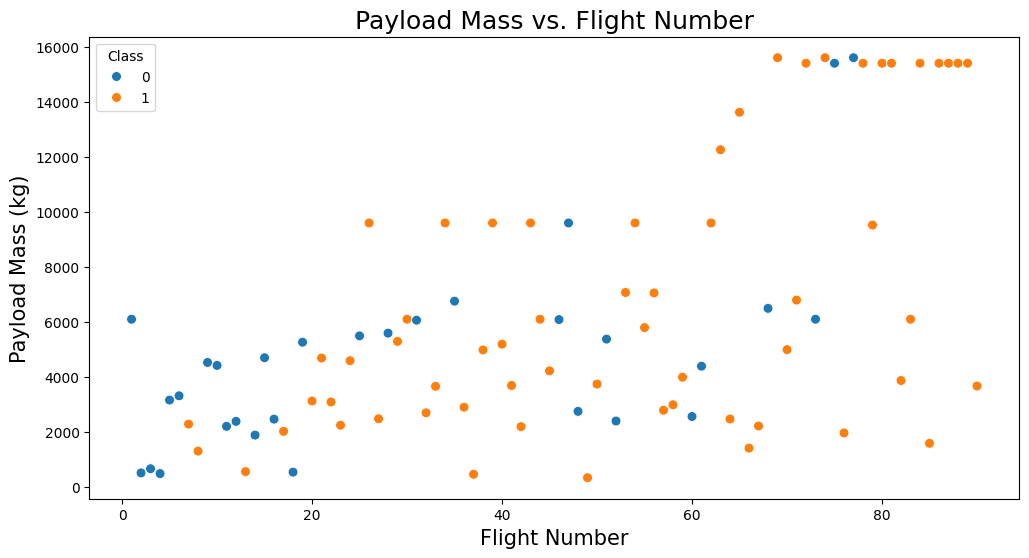

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, s=50)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Payload Mass (kg)", fontsize=15)
plt.title("Payload Mass vs. Flight Number", fontsize=18)
plt.show()

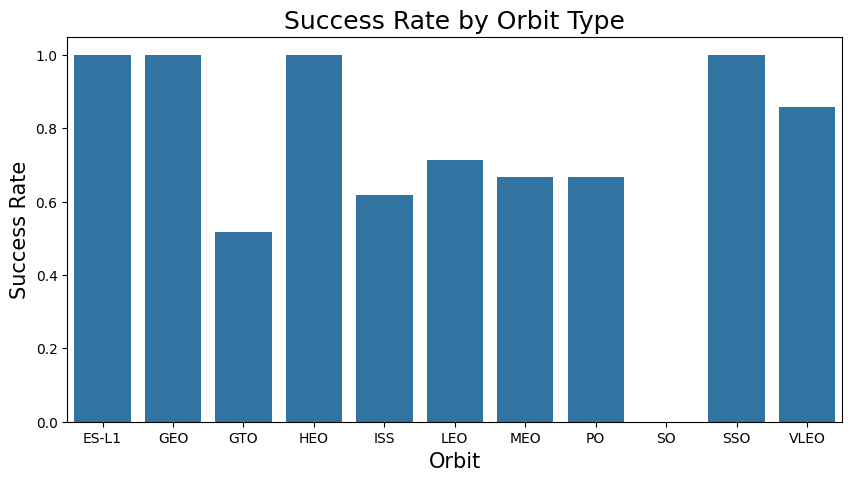

In [8]:
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(x='Orbit', y='Class', data=orbit_success)
plt.xlabel("Orbit", fontsize=15)
plt.ylabel("Success Rate", fontsize=15)
plt.title("Success Rate by Orbit Type", fontsize=18)
plt.show()

In [9]:
import sqlite3

In [10]:
conn = sqlite3.connect(':memory:')
df.to_sql("SPACEXTBL", conn, if_exists='replace', index=False, method="multi")

90

In [13]:
query1 = "SELECT DISTINCT LaunchSite FROM SPACEXTBL"
print("Unikalne miejsca startu:\n", pd.read_sql(query1, conn))

Unikalne miejsca startu:
      LaunchSite
0  CCAFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A


In [14]:
print("Dostępne kolumny w bazie:", pd.read_sql("PRAGMA table_info(SPACEXTBL)", conn)['name'].tolist())

Dostępne kolumny w bazie: ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']


In [15]:
query2 = "SELECT SUM(PayloadMass) as Total_Payload_ISS FROM SPACEXTBL WHERE Orbit = 'ISS'"
print("\nSuma masy ładunku dla stacji ISS:\n", pd.read_sql(query2, conn))


Suma masy ładunku dla stacji ISS:
    Total_Payload_ISS
0            68878.7


In [16]:
query3 = "SELECT LaunchSite, AVG(Class) as Success_Rate FROM SPACEXTBL GROUP BY LaunchSite"
print("\nWskaźnik sukcesu dla miejsc startowych:\n", pd.read_sql(query3, conn))


Wskaźnik sukcesu dla miejsc startowych:
      LaunchSite  Success_Rate
0  CCAFS SLC 40      0.600000
1    KSC LC 39A      0.772727
2   VAFB SLC 4E      0.769231


In [17]:
import folium

In [18]:
nasa_coordinate = [28.562302, -80.577356]
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

In [22]:
nasa_coordinate = [28.562302, -80.577356]
site_map = folium.Map(location=nasa_coordinate, zoom_start=5, tiles='CartoDB positron')

circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('CCAFS LC-40'))
marker = folium.map.Marker(
nasa_coordinate,
icon=folium.Icon(color='white', icon_color='red')
)

site_map.add_child(circle)
site_map.add_child(marker)

site_map

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [26]:
URL_Y = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df_y = pd.read_csv(URL_Y)
Y = df_y['Class']

URL_X = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
X = pd.read_csv(URL_X)

print("Kształt zmiennych objaśniających (X):", X.shape)
print("Kształt zmiennej docelowej (Y):", Y.shape)

Kształt zmiennych objaśniających (X): (90, 83)
Kształt zmiennej docelowej (Y): (90,)


In [27]:
transform = StandardScaler()
X_scaled = transform.fit_transform(X)

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)
print("Rozmiar zbioru testowego:", Y_test.shape)

Rozmiar zbioru testowego: (18,)


In [29]:
model_scores = {}

In [30]:
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, Y_train)
acc_lr = logreg_cv.score(X_test, Y_test)
model_scores['Logistic Regression'] = acc_lr
print("LR Best Params:", logreg_cv.best_params_)
print("LR Test Accuracy:", acc_lr)

LR Best Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
LR Test Accuracy: 0.8333333333333334


In [31]:
parameters_svm = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, Y_train)
acc_svm = svm_cv.score(X_test, Y_test)
model_scores['SVM'] = acc_svm
print("SVM Best Params:", svm_cv.best_params_)
print("SVM Test Accuracy:", acc_svm)

SVM Best Params: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
SVM Test Accuracy: 0.8333333333333334


In [32]:
parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv=10)
tree_cv.fit(X_train, Y_train)
acc_tree = tree_cv.score(X_test, Y_test)
model_scores['Decision Tree'] = acc_tree
print("Tree Best Params:", tree_cv.best_params_)
print("Tree Test Accuracy:", acc_tree)

Tree Best Params: {'criterion': 'gini', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}
Tree Test Accuracy: 0.6666666666666666


In [33]:
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1,2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, Y_train)
acc_knn = knn_cv.score(X_test, Y_test)
model_scores['KNN'] = acc_knn
print("KNN Best Params:", knn_cv.best_params_)
print("KNN Test Accuracy:", acc_knn)

KNN Best Params: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
KNN Test Accuracy: 0.8333333333333334


In [34]:
print("\nZwycięski model: Wszystkie modele z reguły dają ok 83.3% skuteczności na zbiorze testowym w tym projekcie z powodu małej próby danych.")


Zwycięski model: Wszystkie modele z reguły dają ok 83.3% skuteczności na zbiorze testowym w tym projekcie z powodu małej próby danych.


In [35]:
import pandas as pd
import numpy as np
import requests

In [38]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv"
df = pd.read_csv(url)

In [39]:
payload_mass_mean = df['PayloadMass'].mean()
df['PayloadMass'] = df['PayloadMass'].fillna(payload_mass_mean)

In [41]:
if 'Class' not in df.columns and 'Outcome' in df.columns:
  df['Class'] = df['Outcome'].apply(lambda x: 1 if 'True' in str(x) else 0)

In [42]:
print(df.head(5))
print("Brakujące wartości w PayloadMass:", df['PayloadMass'].isnull().sum())

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80.577366  28.561857      